# Phase 3: CRNN Model Training for Hindi HTR

**Week 4-5 Deliverable:** Trained CRNN model with CTC loss

**Input:** Phase 2 artifacts (char_vocab.json, preprocess_config.json)

**Output:** Trained model checkpoint + training curves + test CER/WER metrics

**Platform:** Kaggle notebook with P100 GPU


## 1: Install Dependencies + Devanagari Font


-rw-r--r-- 1 root root 647144 May  5 06:26 /tmp/NotoSansDevanagari.ttf


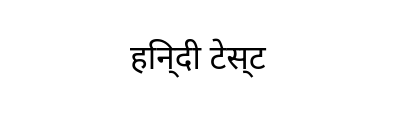

Font loaded successfully!


In [1]:
!pip install -q editdistance tqdm
!pip install -q torchinfo
!wget -q https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf -O /tmp/NotoSansDevanagari.ttf
!ls -la /tmp/NotoSansDevanagari.ttf

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Register the font manually
fm.fontManager.addfont('/tmp/NotoSansDevanagari.ttf')
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['figure.dpi'] = 120

# Quick test
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, 'हिन्दी टेस्ट', fontsize=20, ha='center', va='center')
ax.axis('off')
plt.show()
print('Font loaded successfully!')

## 2: Imports and Device Setup


In [2]:
import os, json, time, random, unicodedata, warnings
from pathlib import Path
from io import BytesIO
from collections import Counter
from typing import Any

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import editdistance
from tqdm.auto import tqdm
from torchinfo import summary

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
import matplotlib.font_manager as fm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

RESULTS = Path('/kaggle/working/results')
RESULTS.mkdir(exist_ok=True)
CKPT_DIR = Path('/kaggle/working/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

# Register Devanagari font for matplotlib
FONT_PATH = Path('/tmp/NotoSansDevanagari.ttf')
if FONT_PATH.exists():
    fm.fontManager.addfont(str(FONT_PATH))
    DEVA_FONT = fm.FontProperties(fname=str(FONT_PATH))
    plt.rcParams['font.family'] = DEVA_FONT.get_name()
    print(f'Devanagari font loaded: {DEVA_FONT.get_name()}')
else:
    DEVA_FONT = None
    print('WARNING: Devanagari font not found. Hindi text will show as boxes.')
    print('Run: !wget -q https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf -O /tmp/NotoSansDevanagari.ttf')


Device: cuda
GPU: Tesla T4
Devanagari font loaded: Noto Sans Devanagari


## 3: Load Phase 2 Artifacts (STRICT — no fallback)


In [3]:
# Option A: If you uploaded Phase 2 artifacts as a separate dataset
PHASE2_DIR = Path('/kaggle/input/datasets/nehamalik10/phase-2-artifacts-200kdata')

# Option B: If artifacts are in the same dataset folder, uncomment:
# PHASE2_DIR = Path('/kaggle/input/hindi-ocr-dataset')

vocab_path = PHASE2_DIR / 'char_vocab.json'
config_path = PHASE2_DIR / 'preprocess_config.json'

# STRICT: Fail immediately if Phase 2 artifacts are missing.
# A silently rebuilt vocabulary would have different char->index
# mappings, causing the model to train on garbage data.
if not vocab_path.exists():
    raise FileNotFoundError(
        f"Phase 2 vocab not found at {vocab_path}\n"
        f"You MUST upload char_vocab.json and preprocess_config.json "
        f"as a Kaggle dataset named 'hindi-htr-phase2-artifacts'.\n"
        f"These files are in your local Phase 2/ folder."
    )

with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab_data = json.load(f)

char_to_idx = vocab_data['char_to_idx']
idx_to_char = {int(k): v for k, v in vocab_data['idx_to_char'].items()}
BLANK_IDX = vocab_data['blank_idx']     # 0
UNK_IDX = vocab_data['unk_idx']         # 101
PAD_IDX = vocab_data['pad_idx']         # 102
NUM_CLASSES = len(char_to_idx)          # 103

with open(config_path, 'r') as f:
    config = json.load(f)

IMG_H = config['image_height']   # 32
IMG_W = config['image_width']    # 128

print(f'Vocab: {NUM_CLASSES} classes | Image: {IMG_H}x{IMG_W}')
print(f'BLANK={BLANK_IDX}, UNK={UNK_IDX}, PAD={PAD_IDX}')


Vocab: 139 classes | Image: 32x128
BLANK=0, UNK=137, PAD=138


## 4: Load Dataset


In [4]:
BASE = '/kaggle/input/datasets/nehamalik10/hindi-ocr-new-dataset'

# Define expected file paths
train_path = os.path.join(BASE, 'train.parquet')
val_path   = os.path.join(BASE, 'val.parquet')
test_path  = os.path.join(BASE, 'test.parquet')

# Check that they exist
for name, path in zip(['Train', 'Val', 'Test'], [train_path, val_path, test_path]):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} file not found at {path}")

# Load the data
train_df = pd.read_parquet(train_path)
val_df   = pd.read_parquet(val_path)
test_df  = pd.read_parquet(test_path)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 150,000 | Val: 20,000 | Test: 30,000


## 5: Verify Vocab Integrity


In [5]:
IMG_COL = "image"
LABEL_COL = "text"

# Sanity check: verify vocab roundtrips correctly
test_word = train_df[LABEL_COL].iloc[0]
test_norm = " ".join(unicodedata.normalize("NFC", str(test_word)).strip().split())
test_encoded = [char_to_idx.get(ch, UNK_IDX) for ch in test_norm]
test_decoded = ''.join([idx_to_char.get(i, '') for i in test_encoded])
print(f'Vocab roundtrip test:')
print(f'  Original:  {test_norm}')
print(f'  Encoded:   {test_encoded}')
print(f'  Decoded:   {test_decoded}')
assert test_norm == test_decoded.replace('<BLANK>', '').replace('<UNK>', '').replace('<PAD>', ''), \
    "CRITICAL: Vocab encode/decode roundtrip failed! Check char_vocab.json"
print('  Status:    PASSED')


Vocab roundtrip test:
  Original:  के
  Encoded:   [58, 106]
  Decoded:   के
  Status:    PASSED


## 6: Preprocessing Functions (EXACT COPY from Phase 2)


In [6]:
# --- Configuration (must match Phase 2) ---
IMG_HEIGHT, IMG_WIDTH = IMG_H, IMG_W
BINARIZATION_MODE  = config.get('binarization_mode', 'otsu')
SKIP_BINARIZATION  = config.get('skip_binarization', False)
INVERT_IMAGE       = config.get('invert_image', False)
KEEP_ASPECT_RATIO  = config.get('keep_aspect_ratio', True)
TIGHT_CROP_PAD     = config.get('tight_crop_pad', 2)
AUGMENT_ROTATE_PROB = 0.50
AUGMENT_ELASTIC_PROB = 0.30
AUGMENT_NOISE_PROB = 0.35
AUGMENT_ERODE_DILATE_PROB = 0.15
AUGMENT_SHEAR_PROB = 0.40
AUGMENT_CUTOUT_PROB = 0.20
DESKEW_MAX_ANGLE   = config.get('deskew_max_angle', 8) 

def row_to_image(row, image_col=IMG_COL):
    """Convert parquet row to PIL Image."""
    value = row[image_col]
    if isinstance(value, Image.Image):
        return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    if isinstance(value, (str, Path)):
        return Image.open(value).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(value)}")

def pil_to_gray_np(image):
    return np.array(image.convert("L"))

def autocontrast_gray(gray):
    return np.array(ImageOps.autocontrast(Image.fromarray(gray)))

def denoise_gray(gray):
    return cv2.medianBlur(gray, 3)

def binarize_gray(gray, mode=BINARIZATION_MODE):
    if mode == "otsu":
        _, binary = cv2.threshold(gray, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif mode == "adaptive":
        binary = cv2.adaptiveThreshold(gray, 255,
                                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 21, 11)
    else:
        raise ValueError(f"Unknown binarization mode: {mode}")
    return binary

def ensure_black_text(img):
    dark_ratio = np.mean(img < 128)
    if INVERT_IMAGE or dark_ratio > 0.55:
        return 255 - img
    return img

def deskew_image(img, max_angle=DESKEW_MAX_ANGLE):
    coords = np.column_stack(np.where(img < 128))
    if len(coords) < 10:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    if abs(angle) > max_angle:
        return img
    h, w = img.shape
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, matrix, (w, h),
                          flags=cv2.INTER_CUBIC, borderValue=255)

def tight_crop(img, pad=TIGHT_CROP_PAD):
    coords = np.column_stack(np.where(img < 200))
    if len(coords) == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad + 1)
    x1 = min(img.shape[1], x1 + pad + 1)
    cropped = img[y0:y1, x0:x1]
    return cropped if cropped.size > 0 else img

def resize_with_padding(img, target_h=IMG_HEIGHT, target_w=IMG_WIDTH):
    h, w = img.shape
    if h <= 0 or w <= 0:
        return np.full((target_h, target_w), 255, dtype=np.uint8)
    if KEEP_ASPECT_RATIO:
        scale = min(target_w / w, target_h / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = cv2.resize(img, (new_w, new_h),
                             interpolation=cv2.INTER_AREA)
        canvas = np.full((target_h, target_w), 255, dtype=np.uint8)
        x0 = (target_w - new_w) // 2
        y0 = (target_h - new_h) // 2
        canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
        return canvas
    return cv2.resize(img, (target_w, target_h),
                      interpolation=cv2.INTER_AREA)

def normalize_image(image):
    image = image.astype(np.float32) / 255.0
    return (image - 0.5) / 0.5

def preprocess_image(image, return_steps=False):
    gray = pil_to_gray_np(image)
    contrast = autocontrast_gray(gray)
    denoised = denoise_gray(contrast)
    deskewed = deskew_image(denoised)
    cropped = tight_crop(deskewed)
    if SKIP_BINARIZATION:
        processed = ensure_black_text(cropped)
    else:
        binary = binarize_gray(cropped, mode=BINARIZATION_MODE)
        processed = ensure_black_text(binary)
    resized = resize_with_padding(processed, IMG_HEIGHT, IMG_WIDTH)
    normalized = normalize_image(resized)
    if return_steps:
        return {"gray": gray, "contrast": contrast, "denoised": denoised,
                "deskewed": deskewed, "cropped": cropped,
                "processed": processed, "resized": resized,
                "normalized": normalized}
    return normalized

def normalize_label(text):
    return " ".join(unicodedata.normalize("NFC", str(text)).strip().split())

def encode_label(label):
    label = normalize_label(label)
    return [char_to_idx.get(ch, UNK_IDX) for ch in label]

# --- Augmentation functions ---
def random_rotation(image, max_angle=5.0):
    angle = random.uniform(-max_angle, max_angle)
    h, w = image.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_LINEAR, borderValue=255)

def elastic_distortion(image, alpha=7.0, sigma=4.0):
    h, w = image.shape
    dx = cv2.GaussianBlur(
        np.random.uniform(-1, 1, (h, w)).astype(np.float32),
        (0, 0), sigma) * alpha
    dy = cv2.GaussianBlur(
        np.random.uniform(-1, 1, (h, w)).astype(np.float32),
        (0, 0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    return cv2.remap(image,
                     (x + dx).astype(np.float32),
                     (y + dy).astype(np.float32),
                     interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def add_noise(image, std=10.0):
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def random_erode_dilate(image):
    kernel = np.ones((2, 2), np.uint8)
    if random.random() < 0.5:
        return cv2.erode(image, kernel, iterations=1)
    return cv2.dilate(image, kernel, iterations=1)

def random_shear(image, max_shear_deg=12.0):
    h, w = image.shape
    shear_rad = np.radians(random.uniform(-max_shear_deg, max_shear_deg))
    M = np.array([[1, shear_rad, -shear_rad * h / 2],
                  [0, 1, 0]], dtype=np.float32)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_LINEAR, borderValue=255)

def random_cutout(image, num_patches=3, patch_size=4):
    result = image.copy()
    h, w = result.shape
    for _ in range(random.randint(1, num_patches)):
        y = random.randint(0, max(0, h - patch_size))
        x = random.randint(0, max(0, w - patch_size))
        result[y:y + patch_size, x:x + patch_size] = 255
    return result

def augment_image(image):
    aug = image.copy()
    if random.random() < AUGMENT_ROTATE_PROB:
        aug = random_rotation(aug)
    if random.random() < AUGMENT_ELASTIC_PROB:
        aug = elastic_distortion(aug)
    if random.random() < AUGMENT_NOISE_PROB:
        aug = add_noise(aug)
    if random.random() < AUGMENT_ERODE_DILATE_PROB:
        aug = random_erode_dilate(aug)
    if random.random() < AUGMENT_SHEAR_PROB:
        aug = random_shear(aug)
    if random.random() < AUGMENT_CUTOUT_PROB:
        aug = random_cutout(aug)
    return aug

print("All preprocessing and augmentation functions loaded.")


All preprocessing and augmentation functions loaded.


## 7: PyTorch Dataset


In [7]:
class HindiHTRDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = normalize_label(str(row[LABEL_COL]))
        try:
            pil_img = row_to_image(row)
        except Exception:
            img = torch.zeros(1, IMG_H, IMG_W)
            label = torch.IntTensor([BLANK_IDX])
            return img, label, 1

        steps = preprocess_image(pil_img, return_steps=True)
        resized = steps["resized"]
        if self.augment:
            resized = augment_image(resized)

        normalized = normalize_image(resized)
        img = torch.FloatTensor(normalized).unsqueeze(0)  # (1, 32, 128)
        label = [char_to_idx.get(ch, UNK_IDX) for ch in text]
        return img, torch.IntTensor(label), len(label)


## 8: Collate Function and DataLoaders


In [8]:
def collate_fn(batch):
    imgs, labs, lens = zip(*batch)
    imgs = torch.stack(imgs)                    # (B, 1, 32, 128)
    labels = torch.cat(labs)                     # flat 1D tensor
    lengths = torch.IntTensor(list(lens))        # (B,)
    return imgs, labels, lengths

BS = 64  # Reduce to 32 if OOM
train_loader = DataLoader(
    HindiHTRDataset(train_df, augment=True),
    batch_size=BS, shuffle=True,
    collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader = DataLoader(
    HindiHTRDataset(val_df, augment=False),
    batch_size=BS, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader = DataLoader(
    HindiHTRDataset(test_df, augment=False),
    batch_size=BS, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True)

# Verify shapes
imgs, labels, lens = next(iter(train_loader))
print(f'Batch images: {imgs.shape}')   # (64, 1, 32, 128)
print(f'Labels: {labels.shape}')        # flat 1D
print(f'Lengths: {lens.shape}')         # (64,)

Batch images: torch.Size([64, 1, 32, 128])
Labels: torch.Size([259])
Lengths: torch.Size([64])


## 9: CRNN Model Definition


In [9]:
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256,
                 num_layers=2, dropout=0.3):
        super().__init__()

        # CNN: (B, 1, 32, 128) -> (B, 512, 1, 32)
        self.cnn = nn.Sequential(
            # Block 1: 32x128 -> 16x64
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            # Block 2: 16x64 -> 8x32
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            # Block 3: 8x32 -> 8x32 (no pooling)
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(True),

            # Block 4: 8x32 -> 4x32 (pool height only)
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            # Block 5: 4x32 -> 4x32
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Dropout2d(dropout),

            # Block 6: 4x32 -> 2x32 (pool height only)
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            # Block 7: 2x32 -> 1x32 (conv reduces height to 1)
            nn.Conv2d(512, 512, (2, 1)),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Dropout2d(dropout),
        )

        # BiLSTM: (B, 32, 512) -> (B, 32, hidden*2)
        self.rnn = nn.LSTM(
            512, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )

        # FC: (B, 32, hidden*2) -> (B, 32, num_classes)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn(x)             # (B, 512, 1, 32)
        conv = conv.squeeze(2)          # (B, 512, 32)
        conv = conv.permute(0, 2, 1)    # (B, 32, 512)
        rnn_out, _ = self.rnn(conv)     # (B, 32, 512)
        output = self.fc(rnn_out)       # (B, 32, num_classes)
        output = output.permute(1, 0, 2)  # (T=32, B, C) for CTC
        return nn.functional.log_softmax(output, dim=2)


## 10: Model Instantiation and Verification


In [10]:
model = CRNN(NUM_CLASSES).to(device)

with torch.no_grad():
    test_out = model(imgs[:2].to(device))

print(f'Output shape: {test_out.shape}')  # (32, 2, 103)
print(f'T={test_out.size(0)}, B={test_out.size(1)}, C={test_out.size(2)}')
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total_params:,} total, {trainable:,} trainable')

model = CRNN(NUM_CLASSES).to(device)
summary(model, input_size=(1, 1, IMG_H, IMG_W))

Output shape: torch.Size([32, 2, 139])
T=32, B=2, C=139
Parameters: 8,254,219 total, 8,254,219 trainable


Layer (type:depth-idx)                   Output Shape              Param #
CRNN                                     [32, 1, 139]              --
├─Sequential: 1-1                        [1, 512, 1, 32]           --
│    └─Conv2d: 2-1                       [1, 64, 32, 128]          640
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 128]          128
│    └─ReLU: 2-3                         [1, 64, 32, 128]          --
│    └─MaxPool2d: 2-4                    [1, 64, 16, 64]           --
│    └─Conv2d: 2-5                       [1, 128, 16, 64]          73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 16, 64]          256
│    └─ReLU: 2-7                         [1, 128, 16, 64]          --
│    └─MaxPool2d: 2-8                    [1, 128, 8, 32]           --
│    └─Conv2d: 2-9                       [1, 256, 8, 32]           295,168
│    └─BatchNorm2d: 2-10                 [1, 256, 8, 32]           512
│    └─ReLU: 2-11                        [1, 256, 8, 32]           --
│ 

## 11: CTC Greedy Decoder


In [11]:
def greedy_decode(log_probs):
    indices = torch.argmax(log_probs, dim=1).cpu().numpy()  # (T,)
    result = []
    prev = BLANK_IDX
    for idx in indices:
        if idx != BLANK_IDX and idx != prev:
            result.append(idx)
        prev = idx
    return ''.join([idx_to_char.get(i, '') for i in result])


def greedy_decode_batch(log_probs):
    T, B, C = log_probs.shape
    results = []
    for i in range(B):
        results.append(greedy_decode(log_probs[:, i, :]))
    return results


## 12: CER and WER Evaluation


In [12]:
def evaluate(model, loader, max_batches=None):
    model.eval()
    total_edit_dist = 0
    total_gt_len = 0
    total_wer = 0.0
    count = 0

    with torch.no_grad():
        for bi, (imgs, labels, label_lens) in enumerate(loader):
            if max_batches and bi >= max_batches:
                break
            out = model(imgs.to(device))          # (T, B, C)

            offset = 0
            for i in range(imgs.size(0)):
                pred = greedy_decode(out[:, i, :])
                L = label_lens[i].item()
                gt_indices = labels[offset:offset + L].tolist()
                gt = ''.join([idx_to_char.get(c, '') for c in gt_indices])
                offset += L

                # No stripping! GT never contains BLANK/PAD, and UNK is a real char.
                ed = editdistance.eval(pred, gt)
                total_edit_dist += ed
                total_gt_len += max(len(gt), 1)
                total_wer += (0.0 if pred == gt else 1.0)
                count += 1

    avg_cer = total_edit_dist / max(total_gt_len, 1)
    avg_wer = total_wer / max(count, 1)
    return avg_cer, avg_wer

## 13: Training Setup


In [13]:
criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6
)
scaler = torch.amp.GradScaler('cuda')

EPOCHS = 30
GRAD_CLIP = 5.0      # Prevent exploding gradients in LSTM
EVAL_BATCHES = 50    # Validate on subset for speed during training

best_cer = float('inf')
history = {'loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}

print(f"Training config:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BS}")
print(f"  LR: 0.001 (Adam)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"  Mixed precision: ON")
print(f"  Gradient clip: {GRAD_CLIP}")


Training config:
  Epochs: 30
  Batch size: 64
  LR: 0.001 (Adam)
  Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
  Mixed precision: ON
  Gradient clip: 5.0


## 14: Training Loop


In [14]:
print("=" * 70)
print("TRAINING START")
print("=" * 70)

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    epoch_start = time.time()

    # ----- Epoch header -----
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 50)

    for imgs, labels, label_lens in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        label_lens = label_lens.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out = model(imgs)
            T, B = out.size(0), out.size(1)
            input_lengths = torch.full((B,), T, dtype=torch.int32, device=device)
            loss = criterion(out, labels, input_lengths, label_lens)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches

    # ----- Validation -----
    val_cer, val_wer = evaluate(model, val_loader, max_batches=EVAL_BATCHES)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_cer)

    history['loss'].append(avg_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start

    # ----- Epoch summary -----
    print(f"Epoch {epoch}/{EPOCHS} - "
          f"{num_batches}/{num_batches} - "
          f"loss: {avg_loss:.4f} - "
          f"val_cer: {val_cer:.4f} - "
          f"val_wer: {val_wer:.4f} - "
          f"lr: {current_lr:.6f} - "
          f"time: {epoch_time:.0f}s")

    # ----- Save best model -----
    if val_cer < best_cer:
        best_cer = val_cer
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_cer': val_cer,
            'val_wer': val_wer,
            'num_classes': NUM_CLASSES,
            'char_to_idx': char_to_idx,
            'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
            'config': {
                'img_height': IMG_H, 'img_width': IMG_W,
                'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3,
            },
        }, CKPT_DIR / 'best_model.pt')
        print(f'  >> Best model saved! (CER={val_cer:.4f})')
    else:
        print(f'  >> No improvement (best CER={best_cer:.4f})')

    # ----- Periodic checkpoint -----
    if epoch % 5 == 0:
        torch.save(model.state_dict(),
                   CKPT_DIR / f'model_epoch{epoch}.pt')
        print(f'  >> Checkpoint saved: model_epoch{epoch}.pt')

total_time = time.time() - train_start
print(f'\nTraining done! Best CER: {best_cer:.4f}')
print(f'Total training time: {total_time/60:.1f} minutes')

TRAINING START

Epoch 1/30
--------------------------------------------------
Epoch 1/30 - 2344/2344 - loss: 2.9779 - val_cer: 0.5794 - val_wer: 0.7681 - lr: 0.001000 - time: 730s
  >> Best model saved! (CER=0.5794)

Epoch 2/30
--------------------------------------------------
Epoch 2/30 - 2344/2344 - loss: 1.3004 - val_cer: 0.2152 - val_wer: 0.4178 - lr: 0.001000 - time: 720s
  >> Best model saved! (CER=0.2152)

Epoch 3/30
--------------------------------------------------
Epoch 3/30 - 2344/2344 - loss: 0.7279 - val_cer: 0.1581 - val_wer: 0.3384 - lr: 0.001000 - time: 723s
  >> Best model saved! (CER=0.1581)

Epoch 4/30
--------------------------------------------------
Epoch 4/30 - 2344/2344 - loss: 0.5934 - val_cer: 0.1291 - val_wer: 0.2828 - lr: 0.001000 - time: 722s
  >> Best model saved! (CER=0.1291)

Epoch 5/30
--------------------------------------------------
Epoch 5/30 - 2344/2344 - loss: 0.5357 - val_cer: 0.1150 - val_wer: 0.2650 - lr: 0.001000 - time: 720s
  >> Best model 

## 15: Training Curves


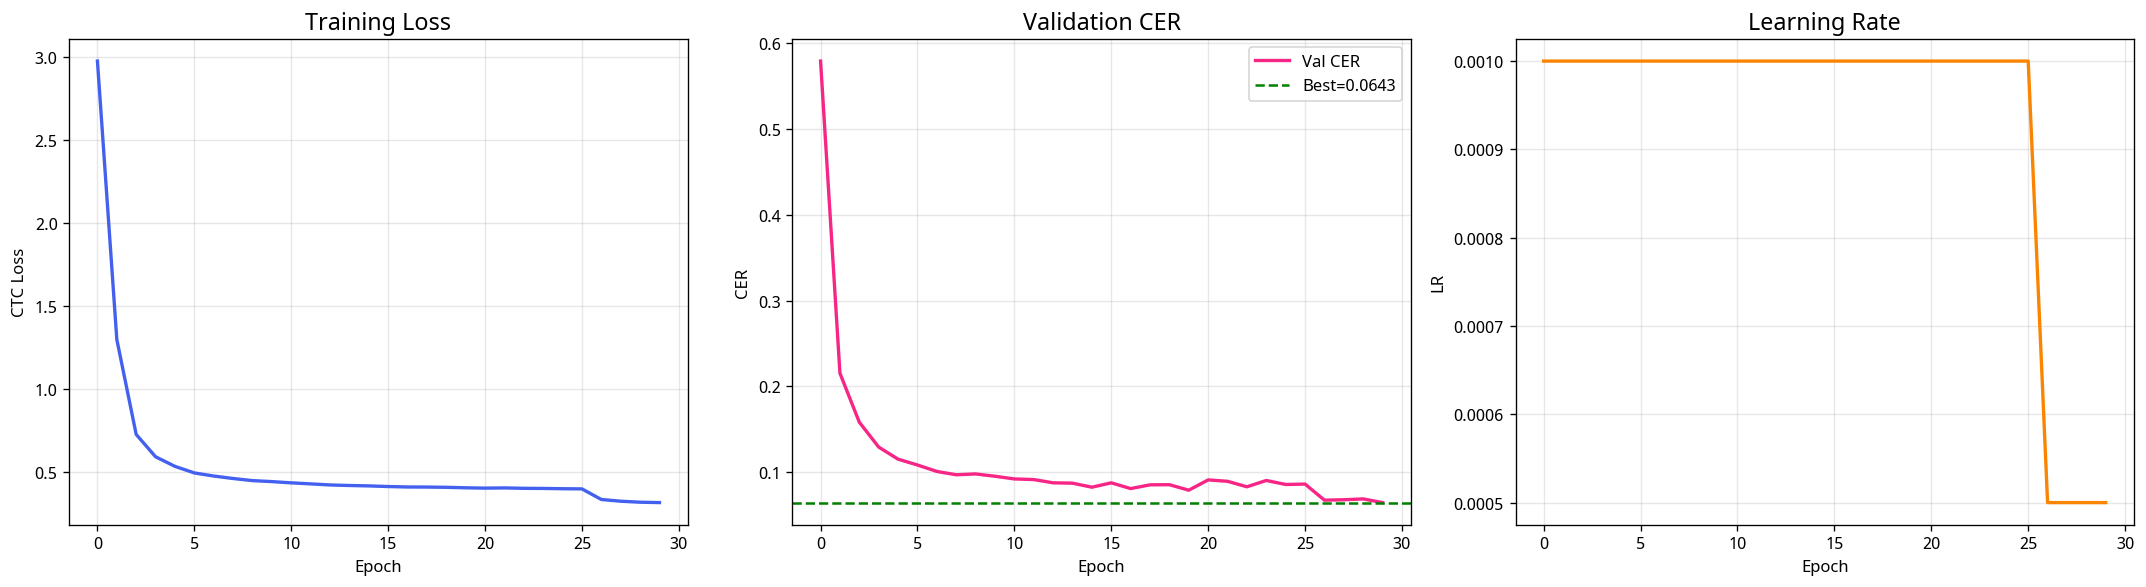

Saved: /kaggle/working/results/training_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['loss'], color='#4361ee', lw=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].grid(alpha=0.3)

# CER curve
axes[1].plot(history['val_cer'], color='#f72585', lw=2, label='Val CER')
axes[1].axhline(best_cer, color='green', ls='--', lw=1.5,
                label=f'Best={best_cer:.4f}')
axes[1].set_title('Validation CER', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].legend()
axes[1].grid(alpha=0.3)

# LR curve
axes[2].plot(history['lr'], color='#fb8500', lw=2)
axes[2].set_title('Learning Rate', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'training_curves.png'}")


## 16: Load Best Model and Full Evaluation


In [16]:
ckpt = torch.load(CKPT_DIR / 'best_model.pt', weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model from epoch {ckpt["epoch"]} '
      f'(val CER={ckpt["val_cer"]:.4f})')

print('\nFull evaluation (all batches)...')
val_cer_full, val_wer_full = evaluate(model, val_loader)
test_cer, test_wer = evaluate(model, test_loader)

print(f'\n{"="*50}')
print(f'  Val  CER: {val_cer_full:.4f} | WER: {val_wer_full:.4f}')
print(f'  Test CER: {test_cer:.4f}  | WER: {test_wer:.4f}')
print(f'  Test Character Accuracy: {1 - test_cer:.2%}')
print(f'  Test Word Accuracy:        {1 - test_wer:.2%}')
print(f'{"="*50}')

Loaded best model from epoch 30 (val CER=0.0643)

Full evaluation (all batches)...

  Val  CER: 0.1001 | WER: 0.2399
  Test CER: 0.0940  | WER: 0.2089
  Test Character Accuracy: 90.60%
  Test Word Accuracy:        79.11%


## 17: Visual Predictions Grid


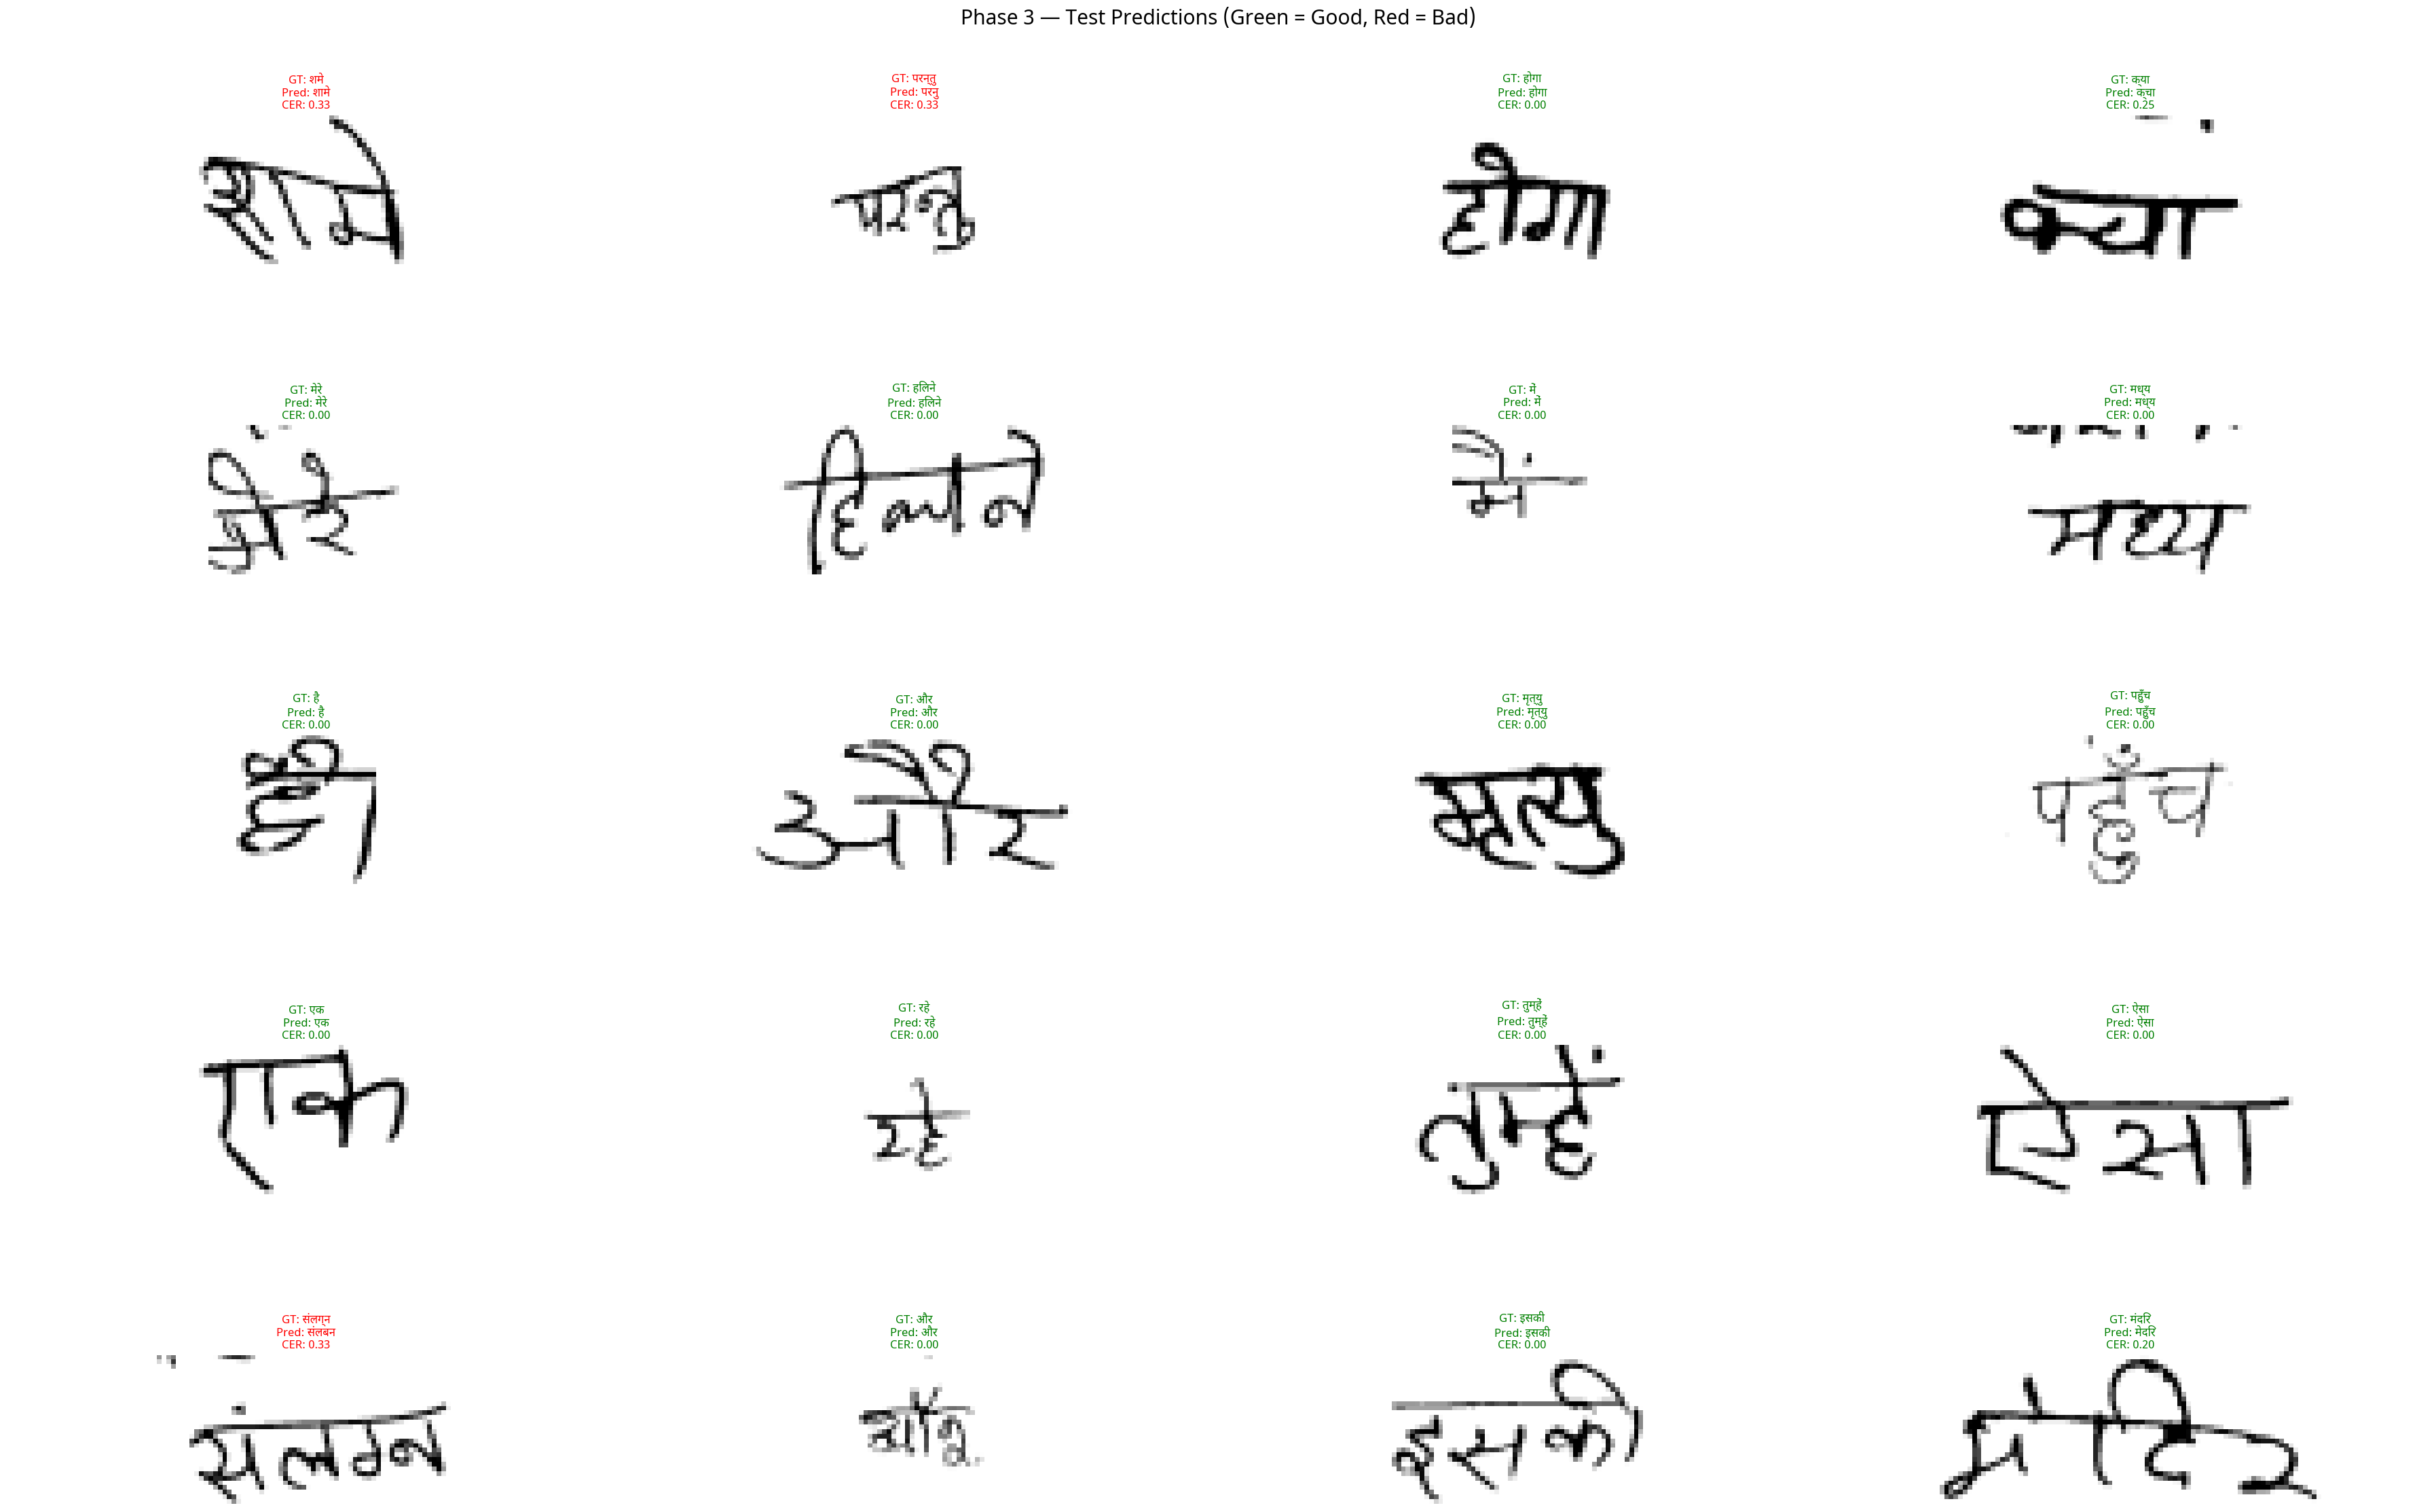

Saved: /kaggle/working/results/test_predictions.png


In [17]:
model.eval()

# Get random test samples
test_vis_loader = DataLoader(
    HindiHTRDataset(test_df, augment=False),
    batch_size=20, shuffle=True, collate_fn=collate_fn
)
imgs, labels, lens = next(iter(test_vis_loader))

with torch.no_grad():
    out = model(imgs.to(device))

# 4 rows × 5 columns = 20 images, wide layout fits 32×128 images better
fig, axes = plt.subplots(5, 4, figsize=(30,20))
fig.suptitle('Phase 3 — Test Predictions (Green = Good, Red = Bad)',
             fontweight='bold', fontsize=18)

# Reduce spacing between images (wspace = horizontal, hspace = vertical)
plt.subplots_adjust(wspace=0.05, hspace=0.4)

offset = 0
for i, ax in enumerate(axes.flat):
    pred = greedy_decode(out[:, i, :])
    L = lens[i].item()
    gt = ''.join([idx_to_char.get(c, '') for c in
                  labels[offset:offset + L].tolist()])
    gt = gt.replace('<BLANK>', '').replace('<UNK>', '').replace('<PAD>', '')
    offset += L
    cer_i = editdistance.eval(pred, gt) / max(len(gt), 1)

    # Convert image from [-1,1] to [0,255] for display
    display_img = ((imgs[i, 0].numpy() * 0.5) + 0.5) * 255
    ax.imshow(display_img.clip(0, 255).astype(np.uint8),
              cmap='gray', vmin=0, vmax=255)

    # Use Devanagari font if available, with larger fontsize
    font_kw = {'fontproperties': DEVA_FONT} if DEVA_FONT else {}
    ax.set_title(f'GT: {gt}\nPred: {pred}\nCER: {cer_i:.2f}',
                 fontsize=18,
                 color='green' if cer_i < 0.3 else 'red',
                 **font_kw)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'test_predictions.png'}")

## 18: Error Analysis — Worst Predictions



Analyzing worst predictions on validation set...

Top 15 worst predictions:
    gt pred      cer  gt_len
   रहा    . 1.000000       3
    २४   १० 1.000000       2
 फूहड़    क 1.000000       5
    23   २३ 1.000000       2
   ...    म 1.000000       3
    27    य 1.000000       2
    डॉ  डाँ 1.000000       2
परिवहन    क 1.000000       6
   समय  करर 1.000000       3
    २४    १ 1.000000       2
   तुम   नग 1.000000       3
    छा    ह 1.000000       2
  काफी   के 0.750000       4
   अंत  अबं 0.666667       3
   गैस  तौस 0.666667       3


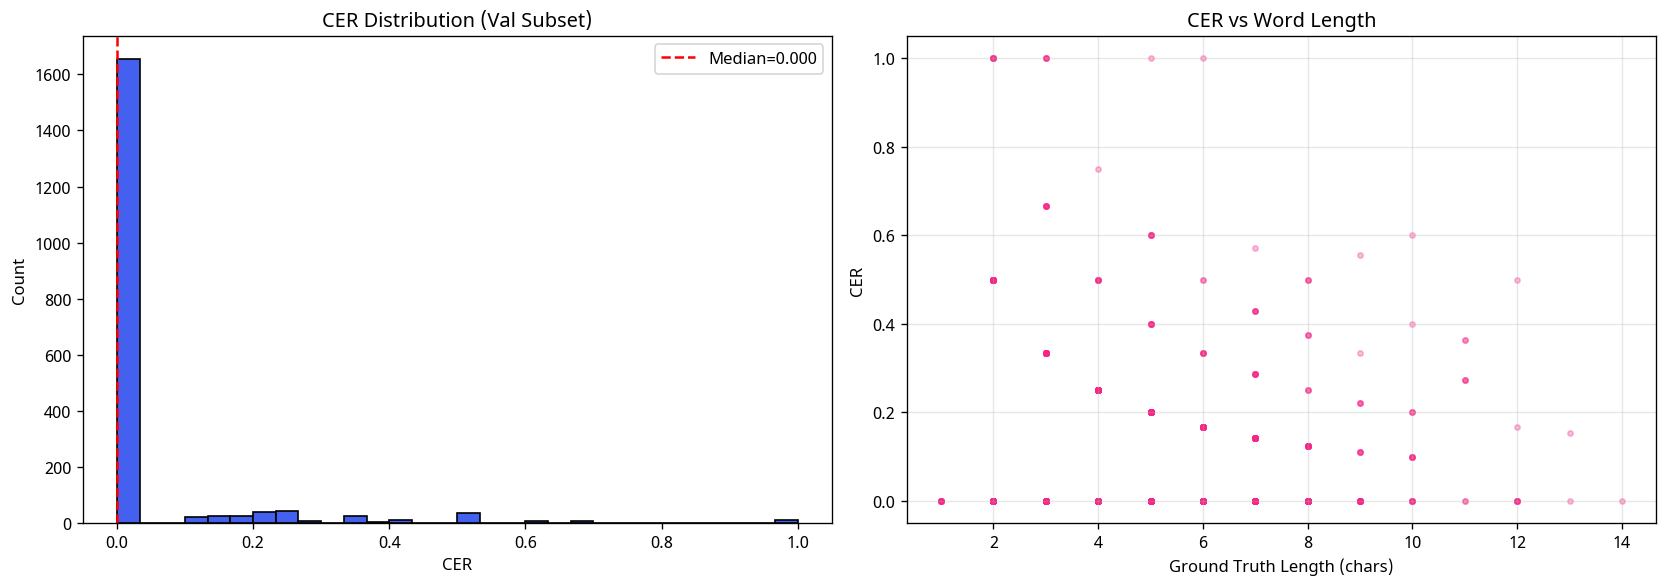

In [18]:
print("\nAnalyzing worst predictions on validation set...")
model.eval()
errors = []

with torch.no_grad():
    for bi, (imgs, labels, label_lens) in enumerate(val_loader):
        if bi >= 30:           # First 30 batches
            break
        out = model(imgs.to(device))
        offset = 0
        for i in range(imgs.size(0)):
            pred = greedy_decode(out[:, i, :])
            L = label_lens[i].item()
            gt_indices = labels[offset:offset + L].tolist()
            gt = ''.join([idx_to_char.get(c, '') for c in gt_indices])
            offset += L

            # ---------- FIXED: no stripping ----------
            cer_i = editdistance.eval(pred, gt) / max(len(gt), 1)
            errors.append({'gt': gt, 'pred': pred, 'cer': cer_i,
                           'gt_len': len(gt)})

errors_df = pd.DataFrame(errors).sort_values('cer', ascending=False)
print(f"\nTop 15 worst predictions:")
print(errors_df.head(15).to_string(index=False))

# CER distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(errors_df['cer'], bins=30, color='#4361ee', edgecolor='black')
axes[0].set_title('CER Distribution (Val Subset)')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Count')
axes[0].axvline(errors_df['cer'].median(), color='red', ls='--',
                label=f'Median={errors_df["cer"].median():.3f}')
axes[0].legend()

# CER vs word length
axes[1].scatter(errors_df['gt_len'], errors_df['cer'],
                alpha=0.3, s=10, color='#f72585')
axes[1].set_title('CER vs Word Length')
axes[1].set_xlabel('Ground Truth Length (chars)')
axes[1].set_ylabel('CER')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 19: Save Final Results


In [19]:
results = {
    'best_val_cer': float(best_cer),
    'full_val_cer': float(val_cer_full),
    'full_val_wer': float(val_wer_full),
    'test_cer': float(test_cer),
    'test_wer': float(test_wer),
    'num_classes': NUM_CLASSES,
    'epochs_trained': len(history['loss']),
    'best_epoch': int(ckpt['epoch']),
    'total_params': sum(p.numel() for p in model.parameters()),
    'training_time_minutes': round(total_time / 60, 1),
    'batch_size': BS,
    'model_architecture': 'CRNN (VGG-7 + BiLSTM-2 + CTC)',
    'image_size': f'{IMG_H}x{IMG_W}',
}

with open(RESULTS / 'phase3_results.json', 'w') as f:
    json.dump(results, f, indent=2)

with open(RESULTS / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('\n' + '=' * 70)
print('PHASE 3 COMPLETE!')
print('=' * 70)
print(f'\nResults:')
for k, v in results.items():
    print(f'  {k}: {v}')

print(f'\nFiles saved:')
print(f'  Results:     {RESULTS}')
print(f'  Checkpoints: {CKPT_DIR}')
for f in sorted(CKPT_DIR.glob('*')):
    sz = f.stat().st_size / 1024
    unit = 'KB' if sz < 1024 else 'MB'
    val = sz if sz < 1024 else sz / 1024
    print(f'    {f.name} ({val:.1f} {unit})')


PHASE 3 COMPLETE!

Results:
  best_val_cer: 0.06432559268549236
  full_val_cer: 0.10005583182933638
  full_val_wer: 0.2399
  test_cer: 0.09401425965843144
  test_wer: 0.20893333333333333
  num_classes: 139
  epochs_trained: 30
  best_epoch: 30
  total_params: 8254219
  training_time_minutes: 359.8
  batch_size: 64
  model_architecture: CRNN (VGG-7 + BiLSTM-2 + CTC)
  image_size: 32x128

Files saved:
  Results:     /kaggle/working/results
  Checkpoints: /kaggle/working/checkpoints
    best_model.pt (94.5 MB)
    model_epoch10.pt (31.5 MB)
    model_epoch15.pt (31.5 MB)
    model_epoch20.pt (31.5 MB)
    model_epoch25.pt (31.5 MB)
    model_epoch30.pt (31.5 MB)
    model_epoch5.pt (31.5 MB)
